# Actividad 3

#### Carga de Datos

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Hitters.csv')

df_beisbol = df[['AtBat', 'Runs']]

print(df_beisbol.head())

   AtBat  Runs
0    293    30
1    315    24
2    479    66
3    496    65
4    321    39


#### Limpieza de Datos

In [30]:
# Vemos cuántos datos nulos hay por columna
print("--- Análisis de Nulos ---")
print(df_beisbol.isnull().sum())

# Vemos un resumen estadístico rápido para detectar errores
print("\n--- Resumen Estadístico ---")
print(df_beisbol.describe())

# Eliminamos filas con nulos, para tener datos puros
df_limpio = df_beisbol.dropna()

print("\n--- Estado Final ---")
print(f"Datos originales: {len(df_beisbol)}")
print(f"Datos tras limpieza: {len(df_limpio)}")

--- Análisis de Nulos ---
AtBat    0
Runs     0
dtype: int64

--- Resumen Estadístico ---
            AtBat        Runs
count  322.000000  322.000000
mean   380.928571   50.909938
std    153.404981   26.024095
min     16.000000    0.000000
25%    255.250000   30.250000
50%    379.500000   48.000000
75%    512.000000   69.000000
max    687.000000  130.000000

--- Estado Final ---
Datos originales: 322
Datos tras limpieza: 322


#### Análisis Exploratorio

La correlación de Pearson entre AtBat y Runs es: 0.9131


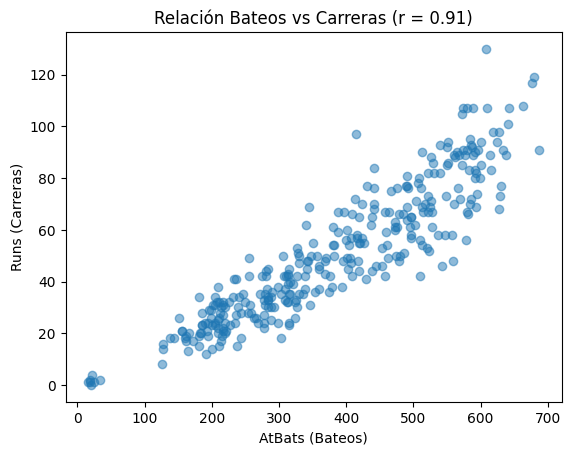

In [31]:
# Calculamos la correlación de Pearson
correlacion = df_limpio['AtBat'].corr(df_limpio['Runs'])

print(f"La correlación de Pearson entre AtBat y Runs es: {correlacion:.4f}")

# Visualización para ver la relación
import matplotlib.pyplot as plt

plt.scatter(df_limpio['AtBat'], df_limpio['Runs'], alpha=0.5)
plt.title(f'Relación Bateos vs Carreras (r = {correlacion:.2f})')
plt.xlabel('AtBats (Bateos)')
plt.ylabel('Runs (Carreras)')
plt.show()

#### Construcción del Modelo

In [32]:
# Definimos X y Y
# X debe ser una matriz 2D
X = df_limpio['AtBat'].values.reshape(-1, 1)
y = df_limpio['Runs'].values

# Dividimos los datos
# test_size=0.2 significa 20% para pruebas
# random_state es para que siempre nos den los mismos resultados al practicar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento: {len(X_train)} registros")
print(f"Set de prueba: {len(X_test)} registros")

Set de entrenamiento: 257 registros
Set de prueba: 65 registros


#### Entrenamineto y Predicción

In [33]:
# Creamos la instancia del modelo
modelo = LinearRegression()

# El modelo aprende del 80% de los datos
modelo.fit(X_train, y_train)

# Con el 20% que hicimos anteriormente de prueba lo usamos
y_pred = modelo.predict(X_test)

# Mostremos 10 predicciones para tener un mejor análisis
print("--- Comparativa: Realidad vs Predicción ---")
for i in range(10):
    print(f"Real: {y_test[i]} | Predicción: {y_pred[i]:.2f}")

--- Comparativa: Realidad vs Predicción ---
Real: 17 | Predicción: 17.72
Real: 22 | Predicción: 35.38
Real: 20 | Predicción: 18.48
Real: 49 | Predicción: 53.95
Real: 67 | Predicción: 53.34
Real: 30 | Predicción: 42.78
Real: 31 | Predicción: 24.36
Real: 35 | Predicción: 44.14
Real: 58 | Predicción: 75.99
Real: 37 | Predicción: 47.76


#### Métricas de error

In [34]:
# Calculamos las métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)

print(f"--- Evaluación del Modelo ---")
print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Error promedio en carreras): {rmse:.2f}")
print(f"R² (Precisión del modelo): {r2:.4f}")

--- Evaluación del Modelo ---
MSE (Error Cuadrático Medio): 111.31
RMSE (Error promedio en carreras): 10.55
R² (Precisión del modelo): 0.8531


### Conclusión y Reflexión

#### Efectividad del modelo.
El modelo es altamente efectivo, gracias a que pudimos calcular la correlación de Pearson inicial que fue de 0.91 y se nos confirma con el coeficiente de determinación con un 0.85 lo cual nos demuestra que los *AtBats* son un predictor primario y confiable para las carreras

#### Aplicabilidad Estratégica
Un mannager puede utilizar este modelo para proyectar el rendimiento de un jugador. si un scout predice que el jugador tendra 500 bateos durante la temporada, el modelo puede estimar con un 85% de confianza cuantas carreras aportara al equipo, lo cual es muy crucial para poder ganar

#### Toma de Decisiones
Basándose en estos datos, el equipo puede decidir si el costo de contratar a un jugador justifica las carreras que se espera que anote, permitiendo una gestión de presupuesto basada en datos, lo cual nos permite saber en donde más podemos invertir para que nuestro equipo cada vez se sienta mas fuerte